<a href="https://colab.research.google.com/github/arpita-py-max/Dimuon-invariant-mass-analysis/blob/main/dimuon_cms_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Objective: Reconstruct the Z boson from dimuon decay channels using CERN CMS Open Data.

Methodology: Applied relativistic invariant mass equations,
performed opposite-sign charge filtering,and used a Gaussian fit to determine resonance parameters.

Result: Successfully identified the Z peak at 90.82 GeV with a detector resolution (σ) of 2.21 GeV.

First five rows:
      Run     Event      pt1    eta1    phi1  Q1    dxy1    iso1      pt2  \
0  165617  74969122  54.7055 -0.4324  2.5742   1 -0.0745  0.4999  34.2464   
1  165617  75138253  24.5872 -2.0522  2.8666  -1 -0.0554  0.0000  28.5389   
2  165617  75887636  31.7386 -2.2595 -1.3323  -1  0.0879  0.0000  30.2344   
3  165617  75779415  39.7394 -0.7123 -0.3123   1  0.0585  0.0000  48.2790   
4  165617  75098104  41.2998 -0.1571 -3.0408   1 -0.0305  1.2280  43.4508   

     eta2    phi2  Q2    dxy2    iso2  
0 -0.9885 -0.4987  -1  0.0712  3.4221  
1  0.3852 -1.9912   1  0.0515  0.0000  
2 -0.4684  1.8833   1 -0.0876  0.0000  
3 -0.1956  2.9703  -1 -0.0492  0.0000  
4  0.5910 -0.0428  -1  0.0442  0.0000  
Run      0
Event    0
pt1      0
eta1     0
phi1     0
Q1       0
dxy1     0
iso1     0
pt2      0
eta2     0
phi2     0
Q2       0
dxy2     0
iso2     0
dtype: int64
Run        int64
Event      int64
pt1      float64
eta1     float64
phi1     float64
Q1         int64
dxy1     fl

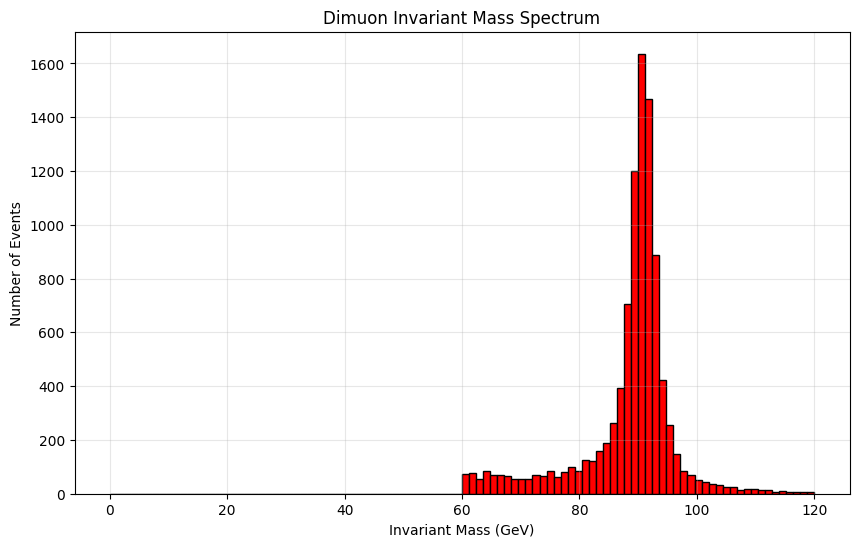

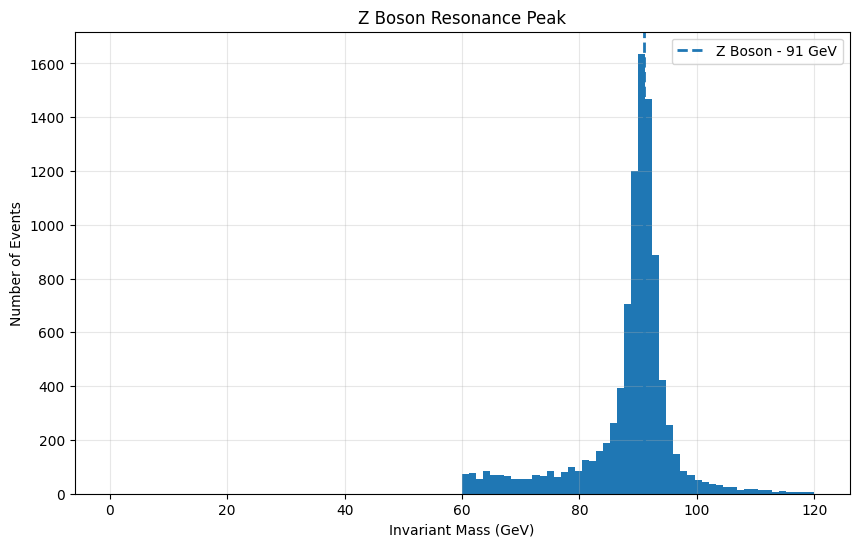


Events between 80 and 100 GeV: 8187
Average Mass in Z region: 90.37349302575056


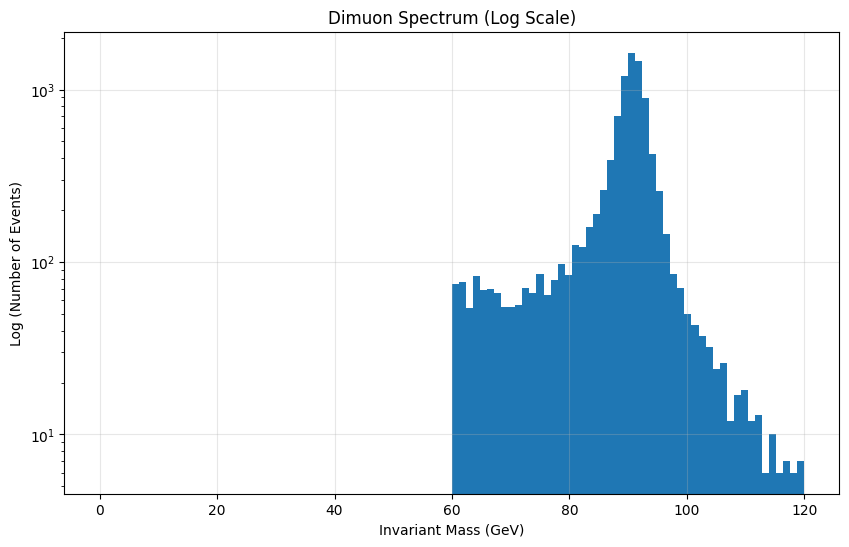

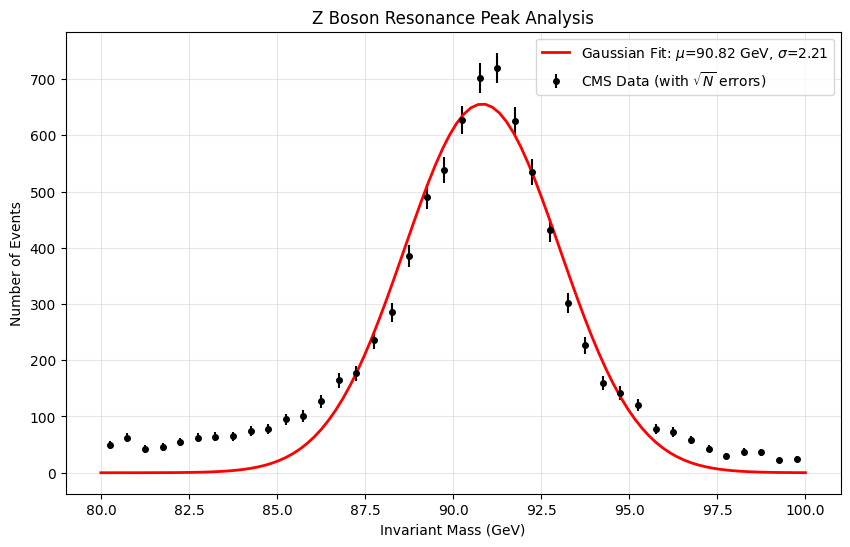

Measured Z Mass: 90.82 GeV
Detector Resolution (Sigma): 2.21 GeV

New file saved: Zmumu_with_mass.csv
 THE MEASURED MASS OF 90.82 GeV IS SLIGHTLT BELOW THE PDG VALUE OF 91.19 Gev.
 This shifts is likely due to energy loss of muons in the detector material or the specific selection cuts applied to the open data sample


In [7]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#DATA CLEANING
df=pd.read_csv("/Zmumu.csv")
df.head()
print("First five rows:")
print(df.head())
print(df.isnull().sum())
df=df.drop_duplicates()
print(df.dtypes)
df=df[(df["pt1"]>0)& (df["pt2"]>0)]
print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)
df=df[df["Q1"] != df["Q2"]]
print("\nAFTER CHARGE FILTERING:", df.shape)

#APPLYING THE FORMULA
mass= np.sqrt(
    2* df["pt1"] * df["pt2"]*
    (
        np.cosh(df["eta1"] - df["eta2"]) - np.cos(df["phi1"]-df["phi2"])
    )
)
df["mass"] = mass
print("\nMass Statistics;")
print(df["mass"].describe())

#plot histograms
plt.figure(figsize=(10,6))
plt.hist(df["mass"], color="red",edgecolor="black",bins=100, range=(0,120))
plt.xlabel("Invariant Mass (GeV)")
plt.ylabel("Number of Events")
plt.grid(alpha=0.3)
plt.title("Dimuon Invariant Mass Spectrum")
plt.show()

#highlight z boson peak
plt.figure(figsize=(10,6))
plt.hist(df["mass"], bins=100,range=(0,120))
plt.axvline(91,linestyle="--",linewidth=2, label="Z Boson - 91 GeV")
plt.xlabel("Invariant Mass (GeV)")
plt.ylabel("Number of Events")
plt.title("Z Boson Resonance Peak")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#count event near Z boson
z_events= df[(df["mass"]>80)&(df["mass"]< 100)]
print("\nEvents between 80 and 100 GeV:", len(z_events))
print("Average Mass in Z region:",z_events['mass'].mean())

#log scale histogram
plt.figure(figsize=(10,6))
plt.hist(df["mass"],bins=100,range=(0,120))
plt.yscale("log")
plt.xlabel("Invariant Mass (GeV)")
plt.ylabel('Log (Number of Events)')
plt.title("Dimuon Spectrum (Log Scale)")
plt.grid(alpha=0.3)
plt.show()

#Define the Gaussian function for the fit
def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

#Select data specifically for the Z peak (80-100 GeV)
z_peak_data = df[(df["mass"] >= 80) & (df["mass"] <= 100)]["mass"]

# Create the histogram data manually to calculate error bars
counts, bin_edges = np.histogram(z_peak_data, bins=40, range=(80, 100))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts) # Poisson uncertainty

# Perform the Fit
# p0 is the initial guess: [amplitude, mean, stddev]
initial_guess = [max(counts), 91, 2]
popt, _ = curve_fit(gaussian, bin_centers, counts, p0=initial_guess)

#Plotting
plt.figure(figsize=(10, 6))

# Plot the data points with error bars
plt.errorbar(bin_centers, counts, yerr=errors, fmt='ko', markersize=4,
             label=r'CMS Data (with $\sqrt{N}$ errors)')

# Plot the Gaussian fit line
x_fit = np.linspace(80, 100, 100)
plt.plot(x_fit, gaussian(x_fit, *popt), 'r-', linewidth=2,
         label=rf'Gaussian Fit: $\mu$={popt[1]:.2f} GeV, $\sigma$={popt[2]:.2f}')

plt.xlabel("Invariant Mass (GeV)")
plt.ylabel("Number of Events")
plt.title("Z Boson Resonance Peak Analysis")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Measured Z Mass: {popt[1]:.2f} GeV")
print(f"Detector Resolution (Sigma): {popt[2]:.2f} GeV")
#saving final data with mass column
df.to_csv("Zmumu_with_mass.csv",
index=False)
print("\nNew file saved: Zmumu_with_mass.csv")
print(" THE MEASURED MASS OF 90.82 GeV IS SLIGHTLT BELOW THE PDG VALUE OF 91.19 Gev.\n This shifts is likely due to energy loss of muons in the detector material or the specific selection cuts applied to the open data sample")